In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, plot_roc_curve
from sklearn.ensemble import GradientBoostingClassifier 

In [26]:
# Load data
file = "../feature_tsv/feature_pruned_pop_subject_removed.tsv"
df = pd.read_csv(file, delimiter="\t")
df

,PPARD_rs4713859,LRP5_rs3736228,CSNK1A1_rs10476909,CSNK1A1_rs1379544,CSNK1A1_rs447950,CSNK1A1_rs414582,CSNK1A1_rs3733658,CSNK1A1_rs2400891,CSNK1A1_rs10062536,LRP5_rs4988300,...,CADD_max_PRKCD,SEX_N_MALE,RADIATION_STATUS_N,AGE_MTX_INITIATION_YEAR,phenotype,EUR,EAS,AMR,AFR,SAS
0,0,0,1,1,0,0,1,1,0,0,...,6.272,0,0,10.983562,0,0.999960,0.000010,0.000010,0.000010,0.000010
1,0,1,1,0,1,0,0,0,0,1,...,6.272,0,0,7.997268,0,0.999953,0.000017,0.000010,0.000010,0.000010
2,0,0,0,1,1,1,1,1,1,0,...,6.272,1,1,16.498630,0,0.664399,0.000010,0.000010,0.134832,0.200750
3,0,0,1,1,0,0,2,2,0,1,...,6.272,0,0,1.802740,0,0.999960,0.000010,0.000010,0.000010,0.000010
4,1,1,1,2,0,0,2,2,0,2,...,6.272,0,0,10.865753,0,0.704421,0.037196,0.257528,0.000010,0.000846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,0,0,1,1,0,0,0,1,0,1,...,6.272,0,0,13.789041,0,0.000010,0.918712,0.000010,0.006736,0.074532
188,1,0,1,0,0,0,1,1,1,1,...,6.272,1,1,3.367123,0,0.450112,0.500935,0.000010,0.000821,0.048122
189,0,0,0,2,1,0,2,2,0,1,...,6.272,1,1,10.484932,0,0.959222,0.000010,0.040575,0.000010,0.000184
190,0,0,0,0,1,1,0,0,0,1,...,12.370,1,0,5.506849,0,0.999779,0.000010,0.000191,0.000010,0.000010


In [27]:
#check NA
df.isna().sum().sum()

0

In [28]:
# Check for None
df.applymap(lambda x: x=="").sum().sum()

0

In [29]:
# Split Data 
X_train, X_test, y_train, y_test = train_test_split(df.drop('phenotype', axis=1), df["phenotype"], test_size=0.2, random_state=0)

In [30]:
# Hyperparameter Tuning
clf = GradientBoostingClassifier(random_state=0)
param = {
    'n_estimators': [40,50,60, 70, 80, 100, 120, 140],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(clf, param, cv=5, n_jobs=-1, verbose=1, return_train_score=True, scoring="roc_auc")

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=0),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
                         'n_estimators': [40, 50, 60, 70, 80, 100, 120, 140]},
             return_train_score=True, scoring='roc_auc', verbose=1)

In [31]:
grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 80}

#### Save the result

In [32]:
best_model_gbdt_pop = grid_search.best_estimator_
%store best_model_gbdt_pop

Stored 'best_model_gbdt_pop' (GradientBoostingClassifier)


In [33]:
%store -r best_model_gbdt_pop

#### Feature Importance

In [34]:
def plot_top_feature_importance(importances, column_names, top_n=20):
         feature_important_series = pd.Series(importances, index=column_names)
         
         # Sort and take the top_n features
         sorted_importances = feature_important_series.sort_values(ascending=False)[0:top_n].iloc[::-1]
         
         # Normalize 
         sorted_importances = 100.0 * (sorted_importances/sorted_importances.max())
         
         plt.figure(figsize=(20,6))
         sorted_importances.plot(kind="barh")
         plt.xlabel('Relative Importance')
         plt.title(f'Top {top_n} Variable Importance')

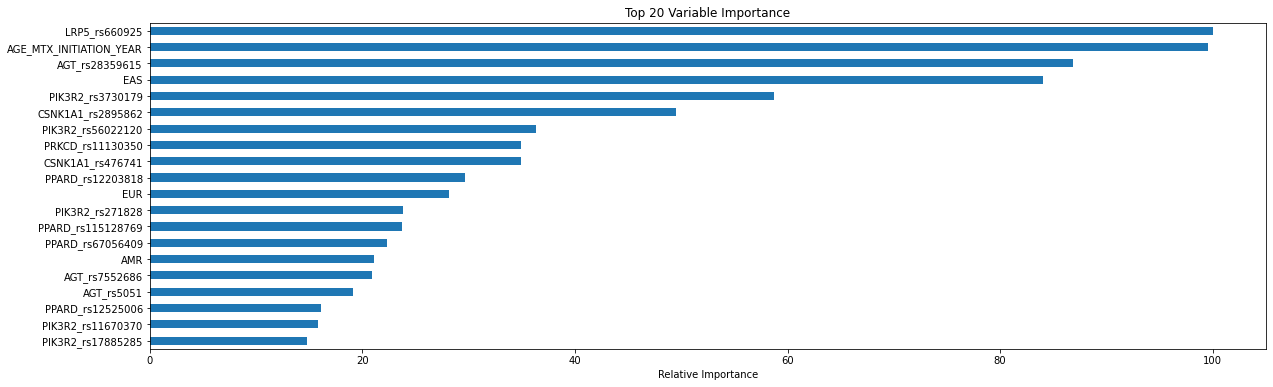

In [35]:
feature_importance = best_model_gbdt_pop.feature_importances_
feature_names = df.drop("phenotype", axis=1).columns

top_importance = plot_top_feature_importance(feature_importance, feature_names, 20)
plt.savefig("../plot/top_importance_full_subject_removed.pdf")

#### Performance Evaluation
* ROC-AUC curve plotting

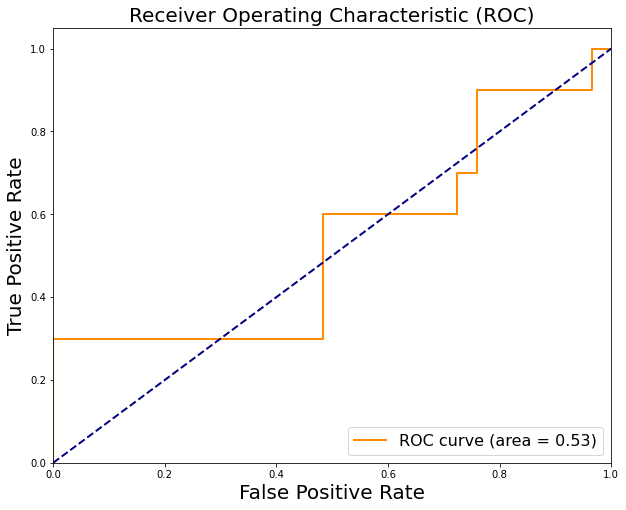

In [39]:
def plot_roc_auc(y_true, y_pred_prob, save_path=None):
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=20)
    plt.ylabel('True Positive Rate', fontsize=20)
    plt.title('Receiver Operating Characteristic (ROC)',fontsize=20)
    plt.legend(loc='lower right', fontsize=16)
    
    if save_path:
        plt.savefig(save_path)
    
    plt.show()
    
if __name__ == "__main__":
    #Predict probabilityes of positive class of each instance
    positive_prob = best_model_gbdt_pop.predict_proba(X_test)[:,1]

    plot_roc_auc(y_test, positive_prob, save_path="../plot/ROC_AUC_full_nomissingsubjects.pdf")

Text(0.5, 15.0, 'Predicted')

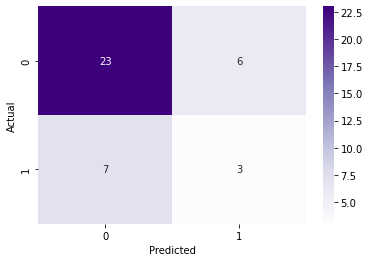

In [40]:
# confusion matrix
y_pred = best_model_gbdt_pop.predict(X_test)
conf = confusion_matrix(y_test, y_pred)
sns.heatmap(conf, annot=True, fmt="d", cmap="Purples", xticklabels=[0,1], yticklabels=[0,1])
plt.ylabel('Actual')
plt.xlabel('Predicted')

npv: 0.77, ppv:0.33, sensitivty0.30, specificity0.79, f1 score0.32


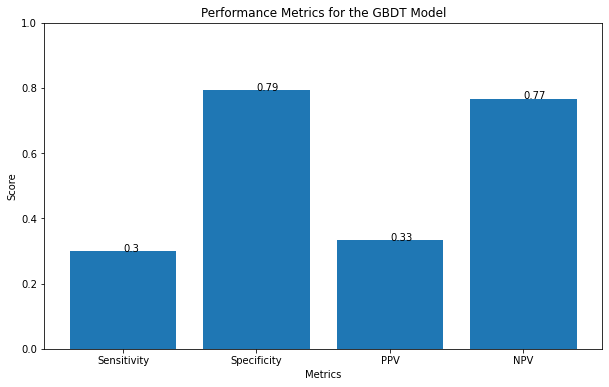

In [41]:
y_pred = best_model_gbdt_pop.predict(X_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# sensitivity aka recall
sensitivity = recall

# specificity
tn, fp, fn, tp = conf.ravel() 
specificity  = tn/(tn+fp)

#ppv 
ppv = tp/(tp+fp)
#npv
npv = tn/(tn+fn)

metrics = [sensitivity, specificity, ppv, npv]
metric_names = ['Sensitivity', 'Specificity', 'PPV', 'NPV']

plt.figure(figsize=(10,6))
plt.bar(metric_names, metrics)
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.ylim([0, 1])
plt.title('Performance Metrics for the GBDT Model')
for index, value in enumerate(metrics):
    plt.text(index, value, str(round(value, 2)))
plt.savefig("../plot/GBDT_performance_subject_removed_pop.pdf")
print(f"npv: {npv:0.2f}, ppv:{ppv:0.2f}, sensitivty{sensitivity:0.2f}, specificity{specificity:0.2f}, f1 score{f1:0.2f}")

#### Ablation Test (without genetic variants)

In [42]:
X_test_ablated_pop = X_test.iloc[:,-7:]
X_train_ablated_pop = X_train.iloc[:,-7:] 

In [44]:
# Hyperparameter Tuning
clf = GradientBoostingClassifier(random_state=0)
param = {
    'n_estimators': [40,50,60, 70, 80, 100, 120, 140],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

grid_search_ablated= GridSearchCV(clf, param, cv=5, n_jobs=-1, verbose=1, return_train_score=True, scoring="roc_auc")

grid_search_ablated.fit(X_train_ablated_pop, y_train)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=0),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
                         'n_estimators': [40, 50, 60, 70, 80, 100, 120, 140]},
             return_train_score=True, scoring='roc_auc', verbose=1)

In [45]:
best_model_gbdt_pop_ablated = grid_search_ablated.best_estimator_
%store best_model_gbdt_pop_ablated

Stored 'best_model_gbdt_pop_ablated' (GradientBoostingClassifier)


In [46]:
%store -r best_model_gbdt_pop_ablated

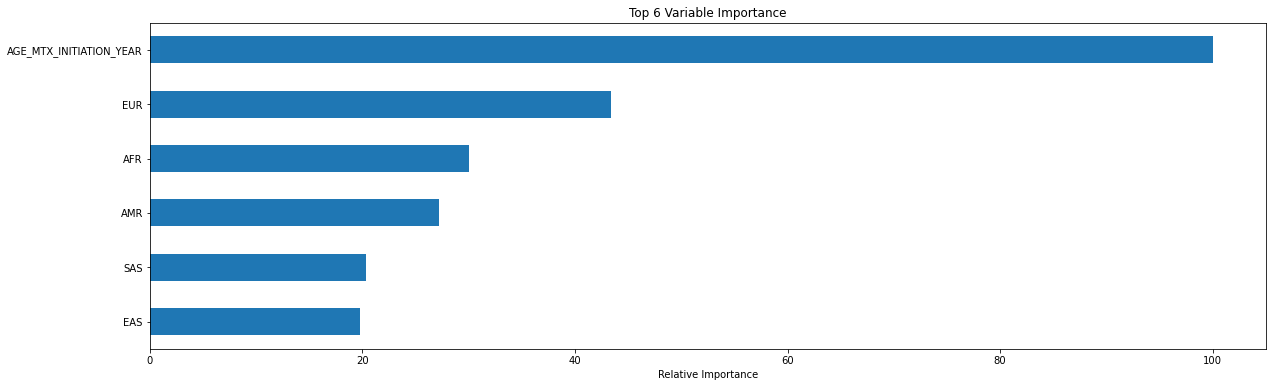

In [47]:
feature_importance = best_model_gbdt_pop_ablated.feature_importances_
feature_names = X_test_ablated_pop.columns

plot_top_feature_importance(feature_importance, feature_names, 6)

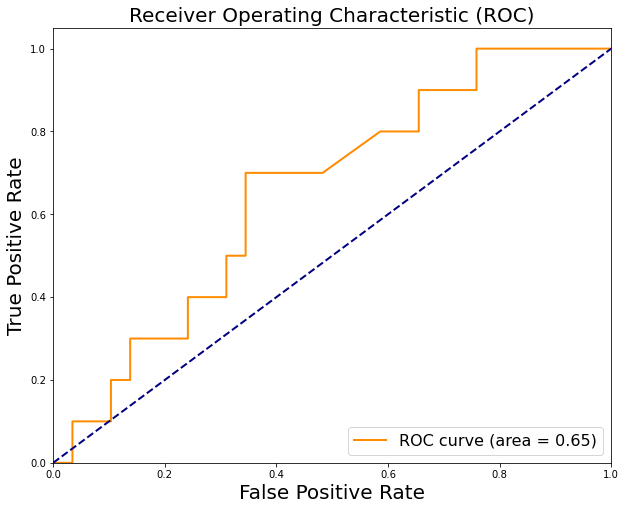

In [48]:
#Predict probabilityes of positive class of each instance
positive_prob = best_model_gbdt_pop_ablated.predict_proba(X_test_ablated)[:,1]

plot_roc_auc(y_test, positive_prob, save_path="../plot/ROC_AUC_ablated_subject_removed_pop.pdf")